In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import plot, Function
from algorithms.rsvd_solvers import MatrixFreeRSVD

from utils.colors import C5, CMAP
from utils.utils import progress_bar
from utils.problem_setup import TestProblemsSetup
from utils.plotting import save_plot
from utils.utils import disk_cache
from utils.metrics import error3

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
PROBLEMS = TestProblemsSetup(n=64).get_test_problems()
RESULTS_FOLDER = '../../results/test_vectors'

In [16]:
@disk_cache(RESULTS_FOLDER)
def experiment(k_range, pid, n, repeat=1, lam=1e-4):
    pb = TestProblemsSetup(n).get_test_problems()[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])

    results = []
    n_steps, step = 3 * len(k_range) * repeat, 1
    for r in range(repeat):
        for k in k_range:
            for d in ['standard', 'rademacher', 'peaks']:
                progress_bar(step, n_steps, end_text=f' [{r=}]')
                step += 1
                
                rsvd.solve(k=k, distribution=d, seed=SEED + k + r)
                w = rsvd.weights()
                x_hat = rsvd.tikhonov_solve(pb['y'], w, lam=lam)
                
                result = {'k': k, 'd': d}
                result.update(error3(x=pb['x'], x_hat=x_hat))
                results.append(result)
    
    return pd.DataFrame(results)


@disk_cache(RESULTS_FOLDER)
def experiment2(k_range, sigma_list, pid, n, repeat=1, lam=1e-4):
    pb = TestProblemsSetup(n).get_test_problems()[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])

    results = []
    n_steps, step = len(sigma_list) * len(k_range) * repeat, 1
    for r in range(repeat):
        for k in k_range:
            for s in sigma_list:
                progress_bar(step, n_steps, end_text=f' [{r=}]')
                step += 1
                
                rsvd.solve(k=k, distribution='peaks', seed=SEED + k + r, sigma=s)
                w = rsvd.weights()
                x_hat = rsvd.tikhonov_solve(pb['y'], w, lam=lam)
                
                result = {'k': k, 's': s}
                result.update(error3(x=pb['x'], x_hat=x_hat))
                results.append(result)
    
    return pd.DataFrame(results)
    

In [17]:
def compute_stats(df):
    df = df.groupby(['k', 'd']).agg(
        euclidean_mean=('euclidean', 'mean'),
        euclidean_std=('euclidean', 'std'),
        emd_mean=('emd', 'mean'),
        emd_std=('emd', 'std'),
        auc_iou_mean=('auc_iou', 'mean'),
        auc_iou_std=('auc_iou', 'std')
    ).reset_index()
    return df

In [18]:
######################## EXPERIMENT 1 ########################
n = 64
repeat = 5
k_range = np.arange(10, 101, 5)

params = [
    {'k_range': k_range, 'pid': 'I',   'n': n, 'repeat': repeat},
    {'k_range': k_range, 'pid': 'II',  'n': n, 'repeat': repeat},
    {'k_range': k_range, 'pid': 'III', 'n': n, 'repeat': repeat}
]
results = [{'params': p, 'df': experiment(**p)} for p in params]
stats = [compute_stats(r['df']) for r in results]

In [19]:
######################## EXPERIMENT 2 ########################
sigma_list = [0.01, 0.1, 0.25, 1.0]

params2 = [
    {'k_range': k_range, 'sigma_list': sigma_list, 'pid': 'I',   'n': n, 'repeat': repeat},
    {'k_range': k_range, 'sigma_list': sigma_list, 'pid': 'II',  'n': n, 'repeat': repeat},
    {'k_range': k_range, 'sigma_list': sigma_list, 'pid': 'III', 'n': n, 'repeat': repeat}
]
results2 = [{'params': p, 'df': experiment2(**p)} for p in params2]
stats2 = [r['df'].groupby(['k', 's']).agg('mean').reset_index() for r in results2]

../../figures/random_vectors_error.png already exists


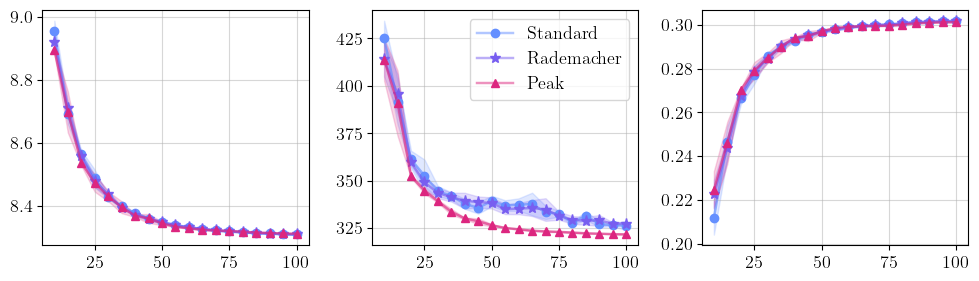

In [20]:
from utils.colors import C3, M, MS
from matplotlib.lines import Line2D
from utils.plotting import save_plot


def plot_df1(df, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    metrics = ['euclidean', 'emd', 'auc_iou']
    distributions = ['standard', 'rademacher', 'peaks']

    for ax, metric in zip(axes.flat, metrics):
        for i, d in enumerate(distributions):
            dfd = df[df.d == d]
            df_mean = dfd[metric + '_mean']
            df_std  = dfd[metric + '_std']

            ax.plot(dfd.k, df_mean, c=C3[i], lw=1.75, alpha=.65)
            ax.plot(dfd.k, df_mean, M[i], c=C3[i], ms=MS[i])
            
            ax.fill_between(
                dfd.k,
                df_mean - df_std,
                df_mean + df_std,
                color=C3[i],
                alpha=0.2
            )

        ax.grid(True, alpha=.5)

    # Custom legends
    handles, labels = [], ['Standard', 'Rademacher', 'Peak']
    for i in range(3):
        legend_line = Line2D([0], [0], color=C3[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C3[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    axes[1].legend(handles=handles, labels=labels)
    plt.tight_layout()

    save_plot(fig_name)
    plt.show()


df = stats[0]
plot_df1(df, 'random_vectors_error')

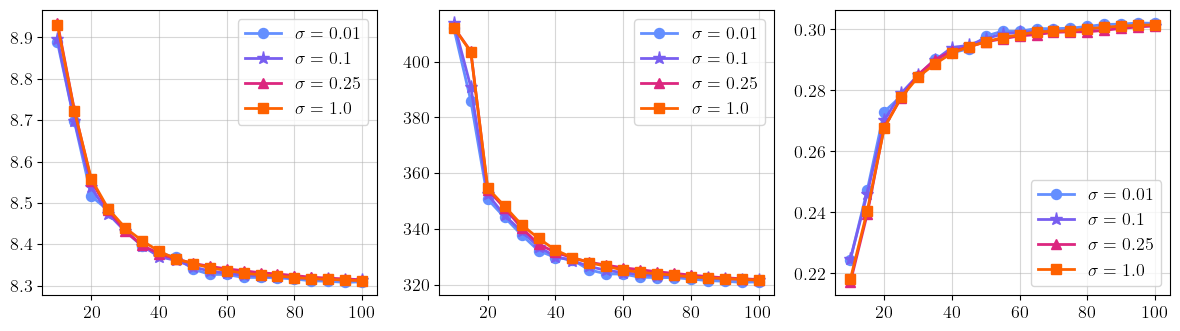

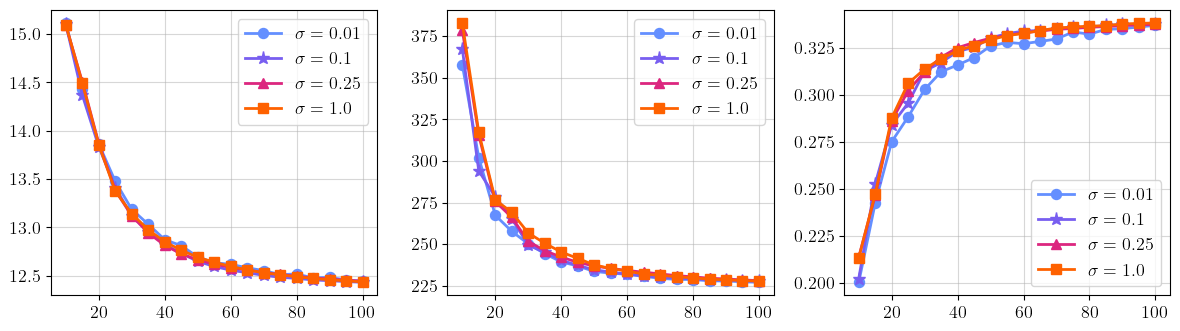

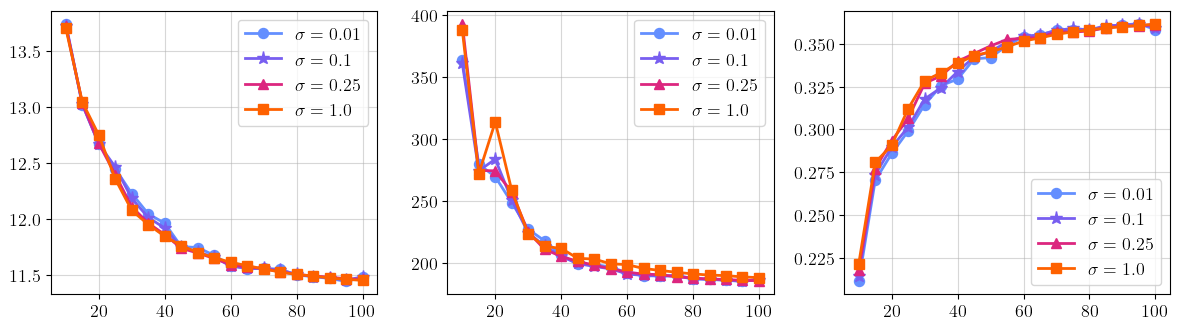

In [21]:
def plot_df2(df):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    metrics = ['euclidean', 'emd', 'auc_iou']
    for ax, metric in zip(axes.flat, metrics):
        for i, s in enumerate(df.s.unique()):
            dfs = df[df.s == s]

            #relative = dfd[metric].values / dfs[metric]
            #ax.plot(dfd.k, relative, f'-{M[i]}', label=d, c=C3[i], lw=2, ms=MS[i] * 1.2)
            ax.plot(dfs.k, dfs[metric], f'-{M[i]}', label=f'$\sigma={s}$', c=C5[i], lw=2, ms=MS[i] * 1.2)

        ax.grid(True, alpha=.5)
        ax.legend()

    plt.tight_layout()
    plt.show()


for df in stats2:
    plot_df2(df)

---
### **Extra Figures**

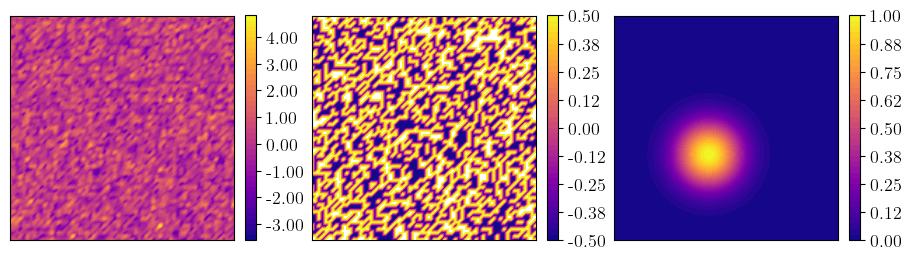

In [27]:
def plot_random_vectors(pid, fig_name=None):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])

    f_standard = Function(pb['V_h'])
    f_rademacher = Function(pb['V_h'])
    f_peaks = Function(pb['V_h'])

    rng = np.random.default_rng(seed=SEED)

    N = pb['V_h'].dim()
    f_standard.vector()[:] = rsvd._draw_random_vector(N, 'standard', rng)
    f_rademacher.vector()[:] = rsvd._draw_random_vector(N, 'rademacher', rng)
    f_peaks.vector()[:] = rsvd._draw_random_vector(N, 'peaks', rng, A=1, sigma=0.1)

    fig, axes = plt.subplots(1, 3, figsize=(9, 6), constrained_layout=True)
    axes = axes.flatten()

    names = ["Standard", "Rademacher", "Peak"]
    #names = [None, None, None]
    sols = [f_standard, f_rademacher, f_peaks]
    for ax, func, name in zip(axes, sols, names):
        plt.sca(ax)
        p = plot(func, cmap=CMAP)
        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.38)
        ax.set_xticks([])
        ax.set_yticks([])
        #ax.set_title(name, fontsize=13)

    save_plot(fig_name)
    plt.show()


plot_random_vectors('I', fig_name='random_test_vectors')

../../figures/clipped_random_vectors.png already exists


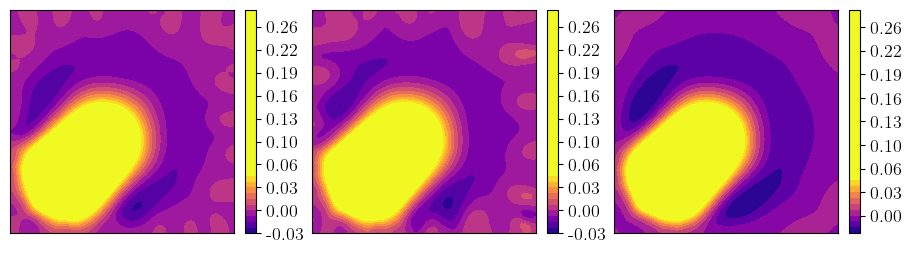

In [23]:
def get_f_from_different_test_vectors(k, pid):
    pb = PROBLEMS[pid]
    distributions = ['standard', 'rademacher', 'peaks']

    rsvd = MatrixFreeRSVD(pb['V_h'])
    f_list = []
    for distribution in distributions:
        U, S, Vt = rsvd.solve(k=k, p=5, distribution=distribution, seed=SEED)
        w = rsvd.weights()
        x_hat = rsvd.tikhonov_solve(pb['y'], w, lam=1e-4)

        f_hat = Function(pb['V_h'])
        f_hat.vector()[:] = x_hat
        f_list.append(f_hat)
    
    return f_list


def plot_multiple_f(f_list, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(9, 6), constrained_layout=True)

    names = [
        "rSVD (standard)",
        "rSVD (rademacher)",
        "rSVD (peaks)"
    ]
    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        p = plot(func, cmap=CMAP, vmax=0.05)
        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.378)
        ax.set_xticks([])
        ax.set_yticks([])
    
    save_plot(fig_name)
    plt.show()


f_list = get_f_from_different_test_vectors(k=50, pid='I')
plot_multiple_f(f_list, 'clipped_random_vectors')

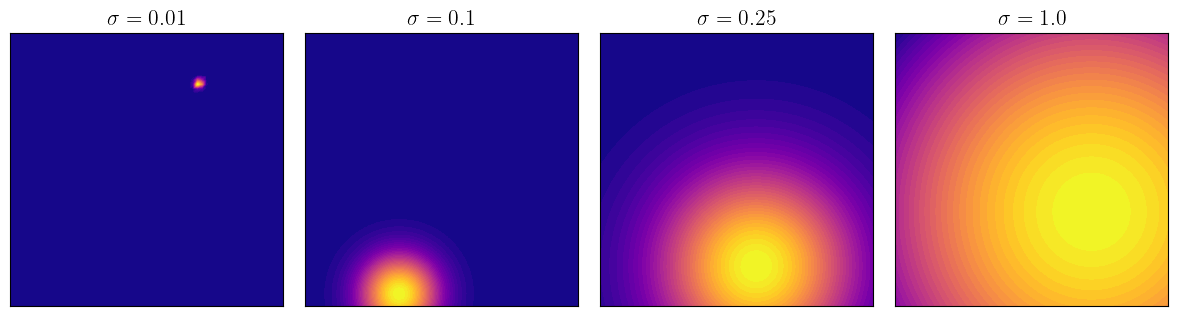

In [24]:
def plot_random_vectors(pid, sigma_list):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h'])
    rng = np.random.default_rng(seed=SEED)

    f_list = []
    for sigma in sigma_list:
        f = Function(pb['V_h'])
        f.vector()[:] = rsvd._draw_random_vector(
            pb['V_h'].dim(), 'peaks', rng, A=1.0, sigma=sigma
        )
        f_list.append(f)


    fig, axes = plt.subplots(1, 4, figsize=(12, 3.15))
    axes = axes.flatten()

    for ax, f, sigma in zip(axes, f_list, sigma_list):
        plt.sca(ax)
        p = plot(f, title=f"$\\sigma={sigma}$", cmap=CMAP)
        #fig.colorbar(p, ax=ax, format="%.2f", shrink=0.38)
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

A_list = [1, 1, 1, 1]
sigma_list = [0.01, 0.1, 0.25, 1.0]
plot_random_vectors('I', sigma_list)

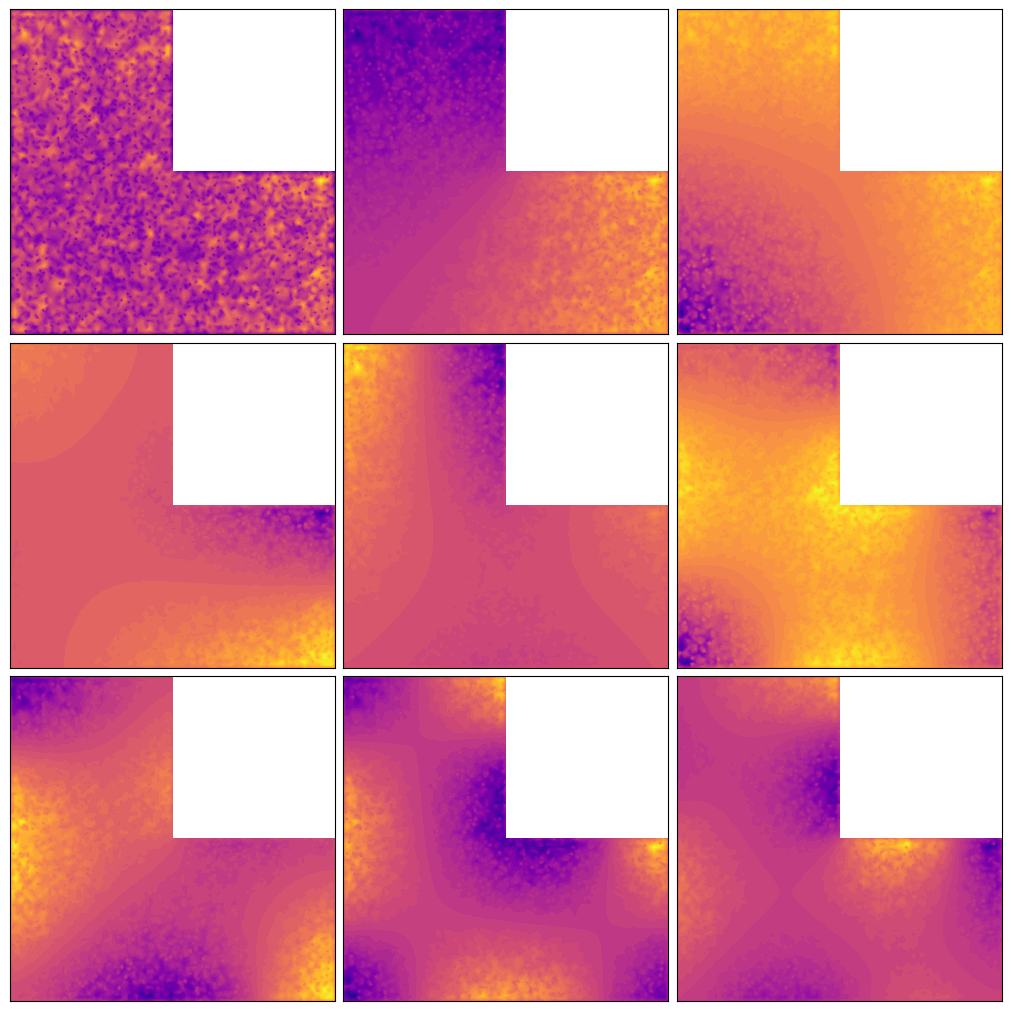

In [25]:
pb = PROBLEMS['III']
rsvd = MatrixFreeRSVD(pb['V_h'])
U, S, Vt = rsvd.solve(k=100, distribution='peaks')

f_list = []
for i in range(0, 9):
    f = Function(pb['V_h'])
    v_i = Vt.T[:, i]
    f.vector()[:] = v_i
    f_list.append(f)

fig, axes = plt.subplots(3, 3, figsize=(10, 10), constrained_layout=True)
for ax, func in zip(axes.flat, f_list):
    plt.sca(ax)
    p = plot(func, cmap=CMAP)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()